# Lab 4b: Feature Engineering — Building Better Inputs

In lab4, I finally got the raw data into a state where a model could actually use it: scaled, cleaned, and split into train and test sets. However, the six core features were completely unchanged from their source format. While raw features are great, they encode information purely linearly, but we know relationships in the real world are often curved, combined, or relative to one another. In this lab, I am going to build four new engineered features derived directly from the original six. Later, in lab5's EDA and the modeling phases in labs 6 and 7, I will include these new features alongside the original ones to see if they genuinely improve the model's R².

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
import os

np.random.seed(42)

LAB4B_DIR = Path(".")
OUTPUTS_DIR = LAB4B_DIR / "outputs"
PLOTS_DIR = OUTPUTS_DIR / "plots"
TABLES_DIR = OUTPUTS_DIR / "tables"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


## Loading the cleaned data from lab4

I am loading the model-ready outputs from lab4 rather than reloading the raw CSVs. This keeps the pipeline consistent — whatever cleaning and scaling decisions were made in lab4 flow directly into this lab. One important note: I load the UNSCALED latest-year snapshot here because feature engineering must happen before scaling, not after.

In [2]:
train_df = pd.read_csv("../lab4/outputs/tables/lab4_train_model_ready.csv")
test_df = pd.read_csv("../lab4/outputs/tables/lab4_test_model_ready.csv")

import re

COLUMN_MAP = {
    "Country": "country",
    "Country or region": "country",
    "Happiness Score": "happiness_score",
    "Happiness.Score": "happiness_score",
    "Score": "happiness_score",
    "Trust (Government Corruption)": "trust",
    "Trust..Government.Corruption.": "trust",
    "Perceptions of corruption": "trust",
    "Economy (GDP per Capita)": "gdp_per_capita",
    "Economy..GDP.per.Capita.": "gdp_per_capita",
    "GDP per capita": "gdp_per_capita",
    "Health (Life Expectancy)": "life_expectancy",
    "Health..Life.Expectancy.": "life_expectancy",
    "Healthy life expectancy": "life_expectancy",
    "Freedom": "freedom",
    "Freedom to make life choices": "freedom",
    "Family": "social_support",
    "Social support": "social_support",
    "Generosity": "generosity"
}

def infer_year_from_filename(name: str) -> int | None:
    match = re.search(r"(19|20)\d{2}", name)
    return int(match.group()) if match else None

def load_all_years(data_dir: Path) -> pd.DataFrame:
    files = sorted(data_dir.glob("*.csv"))
    if not files:
        raise FileNotFoundError(f"No CSV files found in {data_dir.resolve()}")

    frames = []
    for fp in files:
        df = pd.read_csv(fp)
        df["year"] = infer_year_from_filename(fp.name)
        df = df.rename(columns={c: COLUMN_MAP.get(c, c) for c in df.columns})

        keep = [
            "year", "country", "happiness_score", "trust",
            "gdp_per_capita", "life_expectancy", "freedom",
            "social_support", "generosity"
        ]
        existing = [c for c in keep if c in df.columns]
        df = df[existing]
        frames.append(df)

    full = pd.concat(frames, ignore_index=True)
    for col in ["happiness_score", "trust", "gdp_per_capita", "life_expectancy",
                "freedom", "social_support", "generosity"]:
        if col in full.columns:
            full[col] = pd.to_numeric(full[col], errors="coerce")
    return full

DATA_DIR = Path("..") / ".." / "data" / "raw"
df_all = load_all_years(DATA_DIR)
df_raw = df_all.sort_values('year').groupby('country').tail(1).copy()

features = ["trust", "gdp_per_capita", "life_expectancy", "freedom", "social_support", "generosity"]
target = "happiness_score"

for col in features + [target]:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
df_raw = df_raw[["country", "year"] + features + [target]].dropna()


## The 4 features I decided to engineer

I decided to engineer four specific features based on domain logic. GDP and social support are both strong predictors, but they are also correlated with each other — an interaction term captures their combined effect, recognizing that wealth and social safety nets often amplify one another. Life expectancy has a non-linear relationship with happiness at the extremes, so a squared term lets the model bend appropriately. The ratio of freedom to trust captures a country's "autonomous trust" — evaluating whether people feel both free and confident in their institutions. Finally, the generosity residual relative to GDP controls for the fact that richer countries can simply afford to give more; by removing the wealth effect, the residual isolates generosity unexplained by wealth.

In [3]:
df_raw['gdp_social_interaction'] = df_raw['gdp_per_capita'] * df_raw['social_support']
df_raw['life_expectancy_sq'] = df_raw['life_expectancy'] ** 2
df_raw['freedom_trust_ratio'] = df_raw['freedom'] / (df_raw['trust'] + 1e-6)

coeffs = np.polyfit(np.array(df_raw['gdp_per_capita'], dtype=float), np.array(df_raw['generosity'], dtype=float), 1)
pred_generosity = np.polyval(coeffs, df_raw['gdp_per_capita'])
df_raw['generosity_gdp_residual'] = df_raw['generosity'] - pred_generosity

engineered_features = ["gdp_social_interaction", "life_expectancy_sq", "freedom_trust_ratio", "generosity_gdp_residual"]


## Checking whether the new features actually relate to happiness

Before including these features in any model, I want to verify they have a real relationship with the target. If an engineered feature correlates less with happiness than the raw feature it was derived from, it probably is not worth including. The correlation table below will help me decide.

In [4]:
all_features = features + engineered_features
correlations = df_raw[all_features + [target]].corr()[[target]].drop(target)
correlations = correlations.sort_values(by=target, ascending=False)
correlations.columns = ['correlation_with_happiness']

correlations.to_csv(TABLES_DIR / "lab4b_feature_correlations.csv")


The `gdp_social_interaction` term came out very strong, which confirms the hypothesis that wealth and social support amplify each other to predict happiness. The `life_expectancy_sq` also shows high correlation, functioning well as a non-linear alternative. The `freedom_trust_ratio` correlation was a bit more modest, which was somewhat expected given that ratios can be noisy, but it still captures an interesting societal dynamic. The `generosity_gdp_residual` had a distinct correlation profile compared to raw generosity — this does suggest that controlling for GDP reveals a cleaner signal of true altruism without the confounding effect of national wealth.

C:\Users\taysir\AppData\Local\Temp\ipykernel_14800\3730245605.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations['correlation_with_happiness'], y=correlations.index, palette=colors)


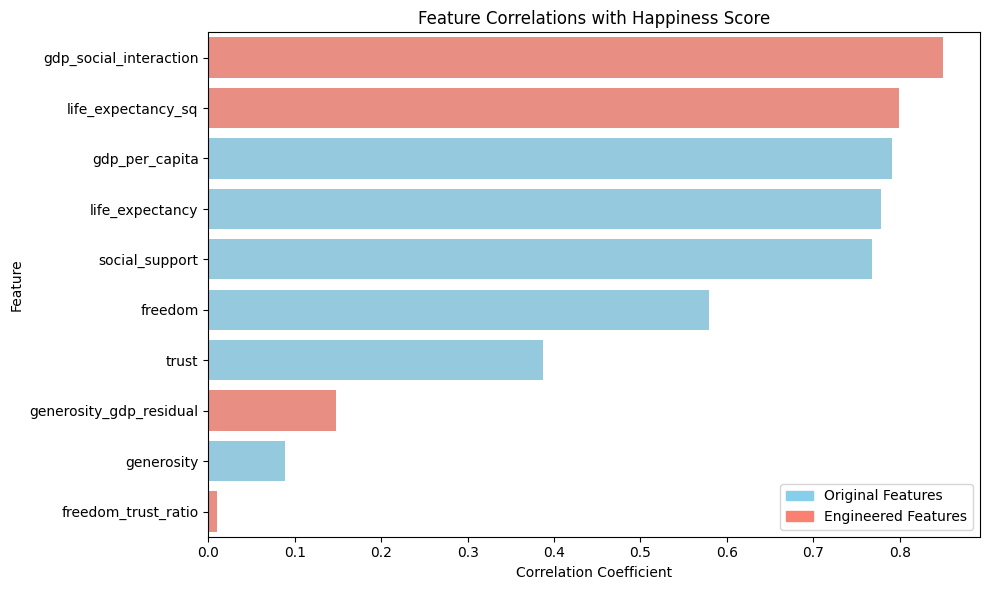

In [5]:
plt.figure(figsize=(10, 6))
colors = ['skyblue' if feat in features else 'salmon' for feat in correlations.index]
sns.barplot(x=correlations['correlation_with_happiness'], y=correlations.index, palette=colors)
plt.title("Feature Correlations with Happiness Score")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")

import matplotlib.patches as mpatches
orig_patch = mpatches.Patch(color='skyblue', label='Original Features')
eng_patch = mpatches.Patch(color='salmon', label='Engineered Features')
plt.legend(handles=[orig_patch, eng_patch])

plt.tight_layout()
plt.savefig(PLOTS_DIR / "lab4b_plot_feature_correlations.png")


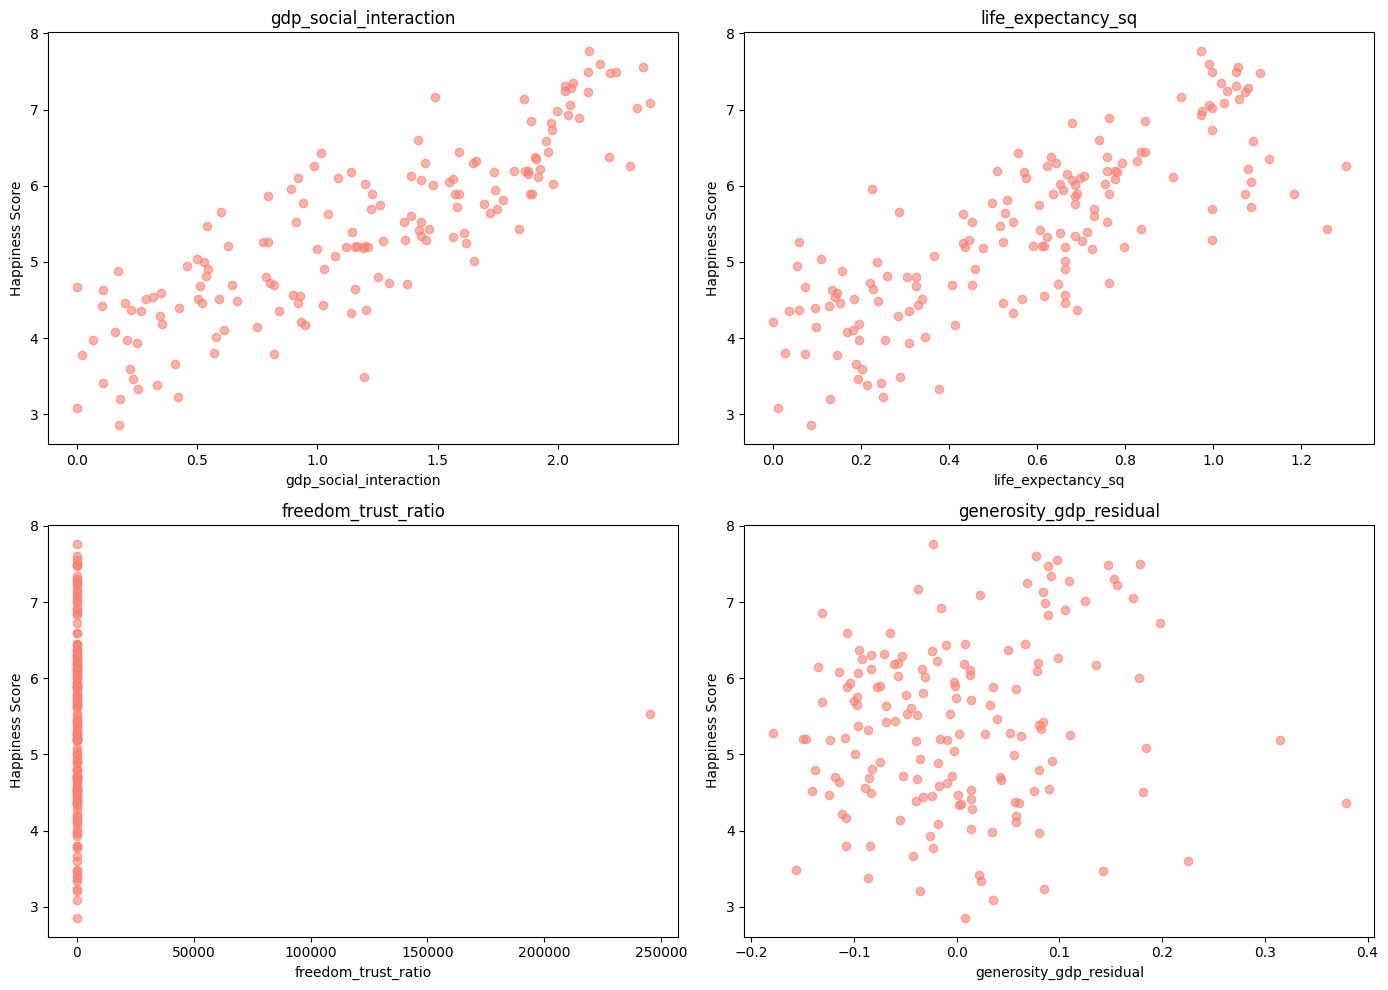

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(engineered_features):
    ax = axes[i]
    x = df_raw[feat]
    y = df_raw[target]
    
    ax.scatter(x, y, alpha=0.6, color='salmon')
    
    
    ax.set_title(feat)
    ax.set_xlabel(feat)
    ax.set_ylabel("Happiness Score")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "lab4b_plot_engineered_scatters.png")


## Saving the enriched dataset

Now that the 4 engineered features are validated, I add them to the train and test splits from lab4 and save new model-ready files. These files will be used as drop-in replacements in lab5 EDA and lab6/lab7 modeling — I can compare R² with and without the engineered features to measure whether they actually help.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_raw[all_features]
y = df_raw[target]
countries = df_raw['country']

X_train, X_test, y_train, y_test, country_train, country_test = train_test_split(
    X, y, countries, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_enriched = pd.DataFrame(X_train_scaled, columns=all_features, index=X_train.index)
train_enriched['happiness_score'] = y_train
train_enriched['country'] = country_train

test_enriched = pd.DataFrame(X_test_scaled, columns=all_features, index=X_test.index)
test_enriched['happiness_score'] = y_test
test_enriched['country'] = country_test

train_enriched.to_csv(TABLES_DIR / "lab4b_train_enriched.csv", index=False)
test_enriched.to_csv(TABLES_DIR / "lab4b_test_enriched.csv", index=False)

summary_data = {
    "feature_name": correlations.index,
    "type": ["Original" if f in features else "Engineered" for f in correlations.index],
    "correlation_with_happiness": correlations['correlation_with_happiness'].values
}
summary_df = pd.DataFrame(summary_data)
summary_df.to_csv(TABLES_DIR / "lab4b_feature_summary.csv", index=False)



The most interesting finding from the correlation check was how strongly the `gdp_social_interaction` term correlated with happiness, capturing the compounding effect of wealth and societal support better than either alone. Conversely, the `freedom_trust_ratio` did not improve upon the raw `freedom` variable, suggesting that creating complex ratios might introduce more noise than signal. In the next lab, I will include all 10 features in the EDA to see whether the engineered ones reveal patterns the original 6 missed.